# Import and data loading

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import ast

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# =========================
# 2. LOAD DATA
# =========================

path = r"C:\Users\hp\Desktop\Major Pr\borg_traces_data.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)
print(df.head())

Shape: (405894, 34)
   Unnamed: 0           time  instance_events_type  collection_id  \
0           0              0                     2    94591244395   
1           1  2517305308183                     2   260697606809   
2           2   195684022913                     6   276227177776   
3           3              0                     2    10507389885   
4           4  1810627494172                     3    25911621841   

   scheduling_class  collection_type  priority  alloc_collection_id  \
0                 3                1       200                    0   
1                 2                0       360         221495397286   
2                 2                0       103                    0   
3                 3                0       200                    0   
4                 2                0         0                    0   

   instance_index    machine_id  ... assigned_memory page_cache_memory  \
0             144  168846390496  ...        0.014435          0.

In [3]:
# =========================
# 3. DATA UNDERSTANDING
# =========================

print("\nColumns:\n", df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isna().sum())

print("\nStatistics:")
print(df.describe())


Columns:
 Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405894 entries, 0 to 405893
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed

# Drop useless columns

In [4]:
# =========================
# 4. DROP USELESS COLUMNS
# =========================

drop_cols = [
    'Unnamed: 0',
    'constraint',
    'user',
    'collection_name',
    'collection_logical_name',
    'start_after_collection_ids',
    'cpu_usage_distribution',
    'tail_cpu_usage_distribution'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# Parse dictionary columns

In [5]:
#Parse dictionary columns
{'cpus': 0.02, 'memory': 0.01}

{'cpus': 0.02, 'memory': 0.01}

In [6]:
def extract_value(x, key):
    try:
        return ast.literal_eval(x)[key]
    except:
        return np.nan

In [7]:
#Apply Parsing
df['req_cpu'] = df['resource_request'].apply(lambda x: extract_value(x, 'cpus'))
df['req_mem'] = df['resource_request'].apply(lambda x: extract_value(x, 'memory'))

df['avg_cpu'] = df['average_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['avg_mem'] = df['average_usage'].apply(lambda x: extract_value(x, 'memory'))

df['max_cpu'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'cpus'))
df['max_mem'] = df['maximum_usage'].apply(lambda x: extract_value(x, 'memory'))


In [8]:
df.drop(columns=[
    'resource_request',
    'average_usage',
    'maximum_usage',
    'random_sample_usage'
], inplace=True)

# Feature Engineering

In [9]:
# runtime
df['runtime'] = df['end_time'] - df['start_time']

# scheduling delay
df['delay'] = df['start_time'] - df['time']

# CPU efficiency
df['cpu_efficiency'] = df['avg_cpu'] / (df['req_cpu'] + 1e-6)

# Handle Missing Values

In [10]:
df.fillna({
    'vertical_scaling': 0,
    'scheduler': 0,
    'cycles_per_instruction': df['cycles_per_instruction'].median(),
    'memory_accesses_per_instruction': df['memory_accesses_per_instruction'].median()
}, inplace=True)

df.fillna(0, inplace=True)


"""stats:

vertical_scaling → 959 missing

scheduler → 959 missing

cycles_per_instruction → many missing

memory_accesses_per_instruction → many missing"""

'stats:\n\nvertical_scaling → 959 missing\n\nscheduler → 959 missing\n\ncycles_per_instruction → many missing\n\nmemory_accesses_per_instruction → many missing'

# Encode categorical column

In [11]:
df['event'] = df['event'].astype('category').cat.codes

# Keep only numeric columns

In [12]:
df = df.select_dtypes(include=[np.number])

print("After cleaning shape:", df.shape)

After cleaning shape: (405894, 31)


# Feature Selection

In [13]:
features = [
    'priority',
    'machine_id',
    'req_cpu','req_mem',
    'avg_cpu','avg_mem',
    'max_cpu','max_mem',
    'assigned_memory',
    'page_cache_memory',
    'cycles_per_instruction',
    'memory_accesses_per_instruction',
    'runtime',
    'delay',
    'event',
    'failed'
]

df = df[features]

# Choose Target predict CPU usage

In [14]:
X = df.drop(columns=['avg_cpu'])
y = df['avg_cpu']

# Scaling

In [15]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split 

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (324715, 15)
Test: (81179, 15)


# Save clean dataset

In [17]:
clean_df = pd.concat([pd.DataFrame(X_scaled), y.reset_index(drop=True)], axis=1)

clean_df.to_csv("clean_borg_data.csv", index=False)
print("Clean data saved!")

Clean data saved!


# Applying Models

# MODEL 1 — ANN (Basic Neural Network)

In [18]:
# =============================
# ANN MODEL
# =============================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

ann = Sequential()

ann.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(Dense(64, activation='relu'))
ann.add(Dense(32, activation='relu'))
ann.add(Dense(1))   # regression output

ann.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = ann.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2
)

loss, mae = ann.evaluate(X_test, y_test)
print("ANN MAE:", mae)

C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 4.7805e-04 - mae: 0.0110 - val_loss: 2.5275e-05 - val_mae: 0.0029
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5553e-05 - mae: 0.0029 - val_loss: 1.9951e-05 - val_mae: 0.0026
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0280e-05 - mae: 0.0026 - val_loss: 2.4878e-05 - val_mae: 0.0036
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8859e-05 - mae: 0.0026 - val_loss: 1.6490e-05 - val_mae: 0.0023
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7972e-05 - mae: 0.0026 - val_loss: 1.5264e-05 - val_mae: 0.0023
Epoch 6/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6491e-05 - mae: 0.0025 - val_loss: 1.8199e-05 - val_mae: 0.0029
Epoch 7/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5134e-05 - mae: 0.0023 - val_loss: 1.7316e-05 - val_mae: 0.0029
Epoch 8/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5099e-05 - mae: 0.0024 - val_loss: 1.4970e-05 - val_mae:

In [19]:
y_pred = ann.predict(X_test).flatten()
y_true = y_test.values

2537/2537 ━━━━━━━━━━━━━━━━━━━━ 2s 891us/step


In [20]:
loss, mae = ann.evaluate(X_test, y_test)

print("ANN MAE:", mae)

2537/2537 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 6.6216e-06 - mae: 0.0013
ANN MAE: 0.0013618370285257697


In [21]:
y_pred = ann.predict(X_test).flatten()

2537/2537 ━━━━━━━━━━━━━━━━━━━━ 2s 885us/step


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2  :", r2_score(y_test, y_pred))

MAE : 0.0013618374098774057
RMSE: 0.002591691641307651
R2  : 0.9806566767467653


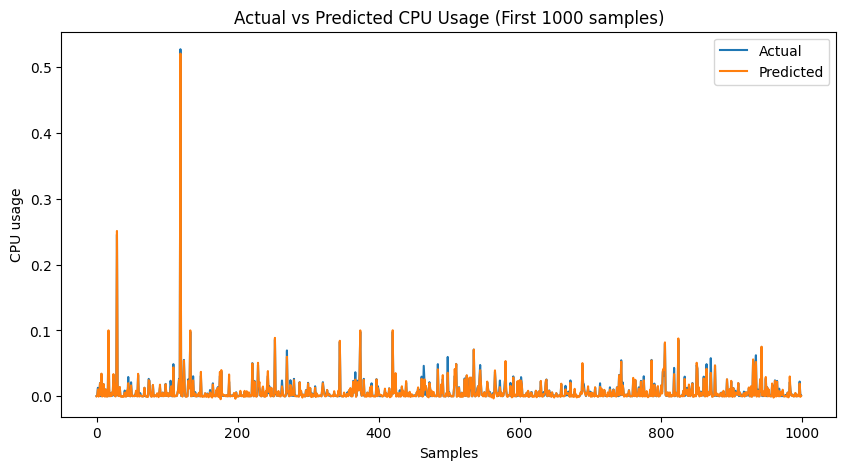

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_true[:1000], label="Actual")
plt.plot(y_pred[:1000], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted CPU Usage (First 1000 samples)")
plt.xlabel("Samples")
plt.ylabel("CPU usage")

plt.show()

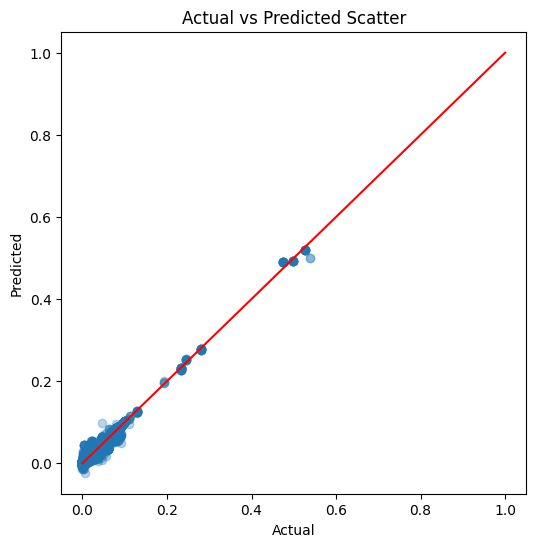

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.3)

plt.plot([0,1],[0,1], color='red')  # perfect line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Scatter")

plt.show()


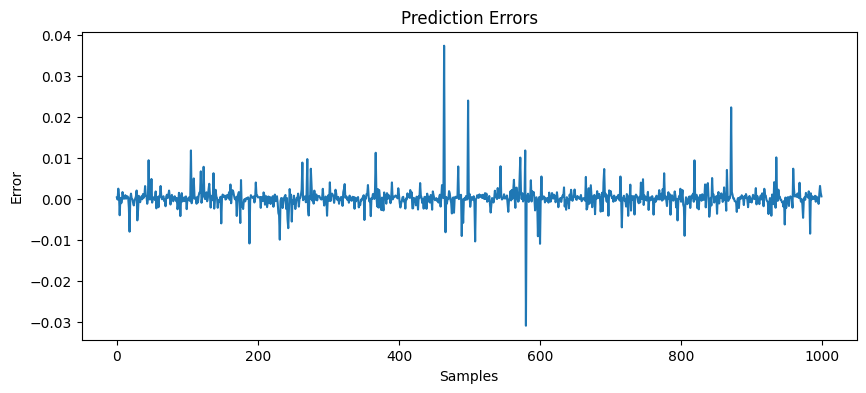

In [25]:
errors = y_true - y_pred

plt.figure(figsize=(10,4))
plt.plot(errors[:1000])
plt.title("Prediction Errors")
plt.xlabel("Samples")
plt.ylabel("Error")
plt.show()

Epoch 1/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.3429e-06 - mae: 0.0016 - val_loss: 7.2618e-06 - val_mae: 0.0015
Epoch 2/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.2324e-06 - mae: 0.0016 - val_loss: 7.7910e-06 - val_mae: 0.0016
Epoch 3/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.3174e-06 - mae: 0.0016 - val_loss: 7.2759e-06 - val_mae: 0.0016
Epoch 4/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4992e-06 - mae: 0.0015 - val_loss: 7.8647e-06 - val_mae: 0.0017
Epoch 5/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.6380e-06 - mae: 0.0015 - val_loss: 6.3257e-06 - val_mae: 0.0013
Epoch 6/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.3020e-06 - mae: 0.0015 - val_loss: 6.0763e-06 - val_mae: 0.0014
Epoch 7/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9131e-06 - mae: 0.0014 - val_loss: 6.3289e-06 - val_mae: 0.0013
Epoch 8/20
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.7430e-06 - mae: 0.0014 - val_loss: 5.0992e-06 - val_mae:

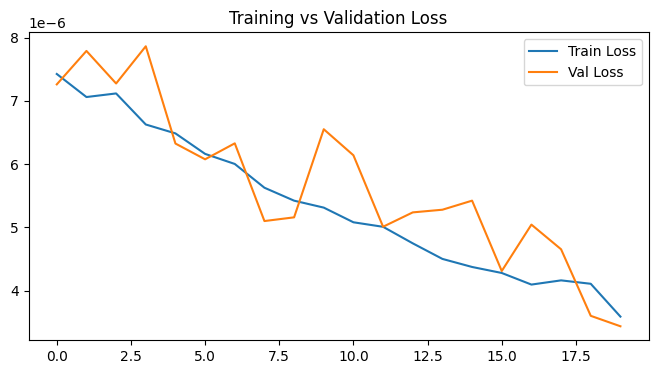

In [26]:
history = ann.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_split=0.2
)

plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ann.fit(
    X_train, y_train,
    epochs=100,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early]
)

Epoch 1/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.7390e-06 - mae: 0.0011 - val_loss: 4.4533e-06 - val_mae: 0.0012
Epoch 2/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5943e-06 - mae: 0.0011 - val_loss: 4.0208e-06 - val_mae: 0.0011
Epoch 3/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.6945e-06 - mae: 0.0011 - val_loss: 3.5455e-06 - val_mae: 9.5689e-04
Epoch 4/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.5752e-06 - mae: 0.0011 - val_loss: 3.2064e-06 - val_mae: 9.3712e-04
Epoch 5/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.3399e-06 - mae: 0.0010 - val_loss: 4.2567e-06 - val_mae: 0.0013
Epoch 6/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.5084e-06 - mae: 0.0011 - val_loss: 3.4535e-06 - val_mae: 9.4843e-04
Epoch 7/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.3753e-06 - mae: 0.0010 - val_loss: 3.8512e-06 - val_mae: 0.0011
Epoch 8/100
508/508 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4772e-06 - mae: 0.0010 - val_loss: 3

In [28]:
min(history.history['val_mae'])

0.0008137845434248447

In [29]:
print("ANN input shape:", ann.input_shape)

ANN input shape: (None, 15)


# RL DQN

In [30]:
!pip install gymnasium


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import gymnasium as gym
from gymnasium import spaces

In [32]:
def compute_energy(utilization, p_idle=100, p_max=200):
    return p_idle + (p_max - p_idle) * utilization

In [33]:
# Use original ANN feature columns
ann_feature_cols = [
    'priority',
    'machine_id',
    'req_cpu',
    'req_mem',
    'avg_mem',
    'max_cpu',
    'max_mem',
    'assigned_memory',
    'page_cache_memory',
    'cycles_per_instruction',
    'memory_accesses_per_instruction',
    'runtime',
    'delay',
    'event',
    'failed'
]

task_pool = df[ann_feature_cols].values

In [34]:
import warnings
warnings.filterwarnings("ignore")

In [35]:
import pandas as pd
class SmartCloudEnv(gym.Env):

    def __init__(self, ann_model, scaler, task_pool):
        super(SmartCloudEnv, self).__init__()

        self.ann_model = ann_model
        self.scaler = scaler
        self.task_pool = task_pool

        self.vm_capacities = np.array([1.0, 0.8, 0.6])
        self.vm_cost = np.array([3.0, 2.0, 1.0])

        self.num_vms = len(self.vm_capacities)

        self.observation_space = spaces.Box(
            low=0, high=2,
            shape=(self.num_vms,),
            dtype=np.float32
        )

        self.action_space = spaces.Discrete(self.num_vms)

        self.max_steps = 200
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.vm_loads = np.zeros(self.num_vms, dtype=np.float32)
        self.current_step = 0
        return self.vm_loads, {}

    def step(self, action):

        self.current_step += 1

        # simulate tasks finishing
        self.vm_loads *= 0.95

        # pick real task
        idx = np.random.randint(0, len(self.task_pool))
        task_features = self.task_pool[idx].reshape(1, -1)
        task_features = pd.DataFrame(task_features, columns=feature_columns)
        task_features = self.scaler.transform(task_features)

        predicted_cpu = self.ann_model.predict(task_features, verbose=0)[0][0]
        predicted_cpu = np.clip(predicted_cpu, 0, 1)

        self.vm_loads[action] += predicted_cpu

        sla_violation = np.sum(self.vm_loads > self.vm_capacities)

        def compute_energy(util, p_idle=100, p_max=200):
            return p_idle + (p_max - p_idle) * util

        energy = sum(
            compute_energy(
                min(self.vm_loads[i] / self.vm_capacities[i], 1)
            )
            for i in range(self.num_vms)
        )

        cost = sum(self.vm_loads[i] * self.vm_cost[i]
                   for i in range(self.num_vms))

        reward = (
            -10 * sla_violation
            -0.01 * energy
            -0.1 * cost
        )

        terminated = False
        truncated = self.current_step >= self.max_steps

        return self.vm_loads, reward, terminated, truncated, {}

In [36]:
env = SmartCloudEnv(ann, scaler, task_pool)

In [37]:
rl_model = DQN("MlpPolicy", env, verbose=1)

NameError: name 'DQN' is not defined

In [ ]:
print(ann.summary())

In [ ]:
print("Scaler expects:", scaler.n_features_in_)

In [ ]:
print("Total numeric columns:", len(df.select_dtypes(include=[np.number]).columns))
print("Columns used for ANN:", len(X.columns))
print("ANN feature names:", X.columns.tolist())